In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

**<font size="6" color="red">ch02. 한글형태소 분석 및 시각화</font>**
# 1. 자연어 처리
- 자연어 : 일상적인 언어
- 자연어 처리 분야
    * 탐색(이해) : 형태소 분석 -> pos tagging(품사태깅) -> 의미분석 또는 시각화
    * 모델 생성 : RNN, LSTM , GRU, seq2seq, transformer
# 2. 자연어 처리 절차
- 분석후보 생성 : 형태소 분리, 품사태깅
- 제약조건 : 규칙 확인 및 불용어 처리
- 분석 : 시각화(워드클라우드, plot), 유사도 분석, 연관분석, RNN, LSTM , GRU, seq2seq, transformer
# 3. 한글 형태소 분석 엔진(Konlpy,...)
- 공통기능 : morphs(형태소 나누기), pos(형태소로 나누어 품사태그), nouns(명사추출)

- Konlpy (pip install konlpy)
    * HanNanum : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Kkma : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Komoran : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Okt
- Mecab(pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양환경에서 사용가능. 다국어바인딩 지원
- Konlp : R용 자연어 처리기

In [2]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [3]:
import konlpy
konlpy.__version__

'0.6.0'

## 3.1 HanNanum 

In [6]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''
text

'아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로\n많이 사용되는 언어입니다\n'

In [8]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                    max_heap_size=512) # 기본값:1024, '1024m', '1g' 최대사이즈 4g
hannanum.analyze(text) # text를 세밀하게 분석해서, 형태소, 품사를 반환(ntag=69로 형태소 분석)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]]]

In [9]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [10]:
# 명사만 추출 : nouns
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [11]:
# 품사 태깅 : pos
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF')]


In [12]:
# ex1. text에서 형용사(PA)만 추출
tagged_text = hannanum.pos(text, ntags=22)
# words = []
# for token, tag in tagged_text:
#     if tag == 'PA':
#         words.append(token)
words = [token for token, tag in tagged_text if tag=='PA']
print(words)

['아름답', '많']


In [ ]:
# ex2. text에서 명사(NC, NQ, NP, NN)만 추출
tags = ['NC', 'NQ', 'NP', 'NN']
words = [token for token, tag in tagged_text if tag in tags]
words

In [ ]:
# ex3. text에서 보통명사(NC)만 추출
tags = ['NC']
words = [token for token, tag in tagged_text if tag in tags]
words

## 3.2 Kkma

In [ ]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [ ]:
from konlpy.tag import Kkma
# kkma = Kkma(jvmpath=None, max_heap_size=1024)
kkma = Kkma()
# 형태소 분석
print(kkma.morphs(text))

In [ ]:
# 품사 태깅
print(kkma.pos(text)) # ntags지정 불가(무조건 56으로)

In [ ]:
# 품사태깅을 이용한 명사(NNG, NNP, NP) 추출
tagged_text = kkma.pos(text)
words = [token for token, tag in tagged_text if tag in ('NNG', 'NNP', 'NP')]
print(words)

In [ ]:
# nouns함수를 이용한 명사 추출
print(kkma.nouns(text))

## 3.3 Komoran

In [3]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [8]:
from konlpy.tag import Komoran
komoran = Komoran()
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [11]:
# 품사태깅(pos tagging)
tagged_list = komoran.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EC')]


In [12]:
# 일반명사(NNG) + 고유명사(NNP) 추출
print([token for token, tag in tagged_list if tag in ('NNG', 'NNP')])


['한국어', '전', '세계', '사용', '언어']


## 3.4 Okt(twitter)
- konlpy v0.4.5부터 Twitter -> Okt로 바뀜
- SNS 텍스트 분석용 개발
- Scala로 개발 -(컴파일)-> . class파일 (JVM위에서 실행)

In [14]:
from konlpy.tag import Twitter, Okt
okt = Okt()
print('명사구 추출 : ', okt.phrases(text))
# 형태소 분석
print('형태소 추출 : ', okt.morphs(text))

명사구 추출 :  ['다소', '한국어', '전세계', '13번째', '사용', '사용되는 언어', '13', '번째', '언어']
형태소 추출 :  ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '\n', '많이', '사용', '되는', '언어', '입니다', '\n']


In [15]:
# 명사만 추출
print(okt.nouns(text))

['다소', '한국어', '전세계', '번', '사용', '언어']


In [17]:
# 품사태깅
tagged_list = okt.pos(text)
print(tagged_list)

[('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('\n', 'Foreign'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('\n', 'Foreign')]


In [19]:
# 명사(Noun)만 추출
print([word for word, tag in tagged_list if tag == 'Noun'])

['다소', '한국어', '전세계', '번', '사용', '언어']


## 3.5 MeCab
- pip install python-mecab-ko
- 압도적 속도(Konlpy 대비 5~20배 빠름)
- 낮은 메모리 사용량
- 형태소 분해 정확도 높음. 네이버, 카카오, 라인 등에서도 mecab 계열을 사용한 사례가 많음

In [20]:
# 형태소 분석
from mecab import MeCab
mecab = MeCab()
print(mecab.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다']


In [21]:
# 명사 추출
print(mecab.nouns(text))

['한국어', '세계', '번', '사용', '언어']


In [22]:
# 품사 태깅
tagged_list = mecab.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EC')]


In [23]:
# 명사(NNG, NNP, NP, NR) 추출
print([token for token, tag in tagged_list if tag in ('NNG', 'NNP', 'NP', 'NR')])

['한국어', '세계', '사용', '언어']


# 4. 말뭉치

In [24]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:30])

[Emma by Jane Austen 1816]

VO


In [26]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [27]:
# 한국어 말뭉치
from konlpy.corpus import kolaw
kolaw_data = kolaw.open('constitution.txt').read()
print('글자수 : ', len(kolaw_data))
print('%r' % kolaw_data[:50])

글자수 :  18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임'


# 5. 워드 클라우드
- pip install wordcloud

In [28]:
nouns = ['word1', 'word2', 'word1']
' '.join(nouns)

'word1 word2 word1'

In [37]:
# 영어 말뭉치에서 2글자 이상의 명사 추출(특수문자 제외)하여 워드클라우드 생성
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret = RegexpTokenizer('[a-zA-Z0-9]{2,}') # \w{2,}
words = ret.tokenize(emma)
emma_tags = pos_tag(words)
# 명사 추출(NN, NNS, NNP, NNPS)
noun_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS', 'NNP', 'NNPS')]
print('추출된 명사 갯수 : ', len(noun_list), '단어 종류수 : ', len(set(noun_list)))
emma_noun = ' '.join(noun_list)
print('워드 클라우드에서 필요한 text : ', emma_noun[:200])

추출된 명사 갯수 :  32488 단어 종류수 :  4012
워드 클라우드에서 필요한 text :  Emma Jane Austen VOLUME CHAPTER Emma Woodhouse clever home disposition blessings existence years world daughters indulgent father consequence marriage mistress house period mother remembrance caresses


In [55]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

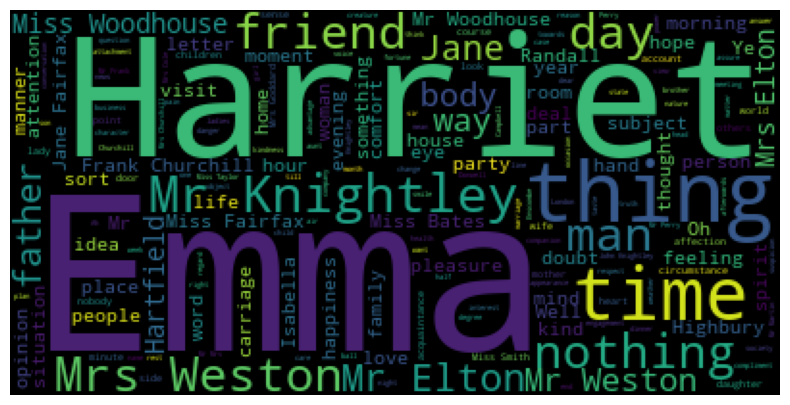

In [58]:
wordcloud = WordCloud()
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

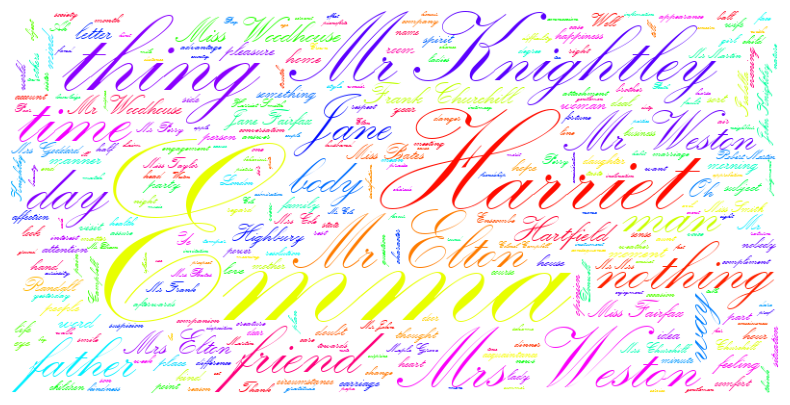

In [60]:
wordcloud = WordCloud(font_path='C:/Windows/Fonts/KUNSTLER.TTF',# 글자 폰트
                      width=800, # 생성될 이미지 가로(픽셀) 기본값은 400
                      height=400, # 생성괼 이미지 세로(픽셀) 기본값은 200
                      background_color='white', # 배경색 white
                      max_words=300, # 표시될 단어의 최대 갯수
                      relative_scaling=0.9, # 단어 빈도에 따른 크기 차이
                      colormap='hsv', # 글끼 색상들(컬러맵)
#                       max_font_size=80, # 최대 폰트 사이즈(픽셀)
#                       min_font_size=10, # 최소 폰트 사이즈
                      )
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [61]:
# 생성된 wordcloud 저장
wordcloud.to_file('emma.jpg') # jpg나 png

In [68]:
# 한글 말뭉치 kolaw_data
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
from nltk import FreqDist
import pandas as pd

analyzer = MeCab()
noun_list = analyzer.nouns(kolaw_data)
noun_list = [word for word, tag in analyzer.pos(kolaw_data) if tag in ('NNG', 'NNP')]
noun_wordcount = FreqDist(noun_list)
wordCnt = pd.Series(noun_wordcount)
wordCnt.sort_values(ascending=False, inplace=True)
wordCnt.head(10)

법률     121
대통령     84
조       79
국가      73
헌법      69
국민      69
국회      69
때       55
필요      31
위원      30
dtype: int64

In [69]:
# 워드 클라우드에서 필요한 text
data_noun = ' '.join(noun_list)
data_noun[:100]

'대한민국 헌법 역사 전통 국민 운동 건립 대한민국 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 인도 동포 애 민족 단결 사회 폐습 불의 타'

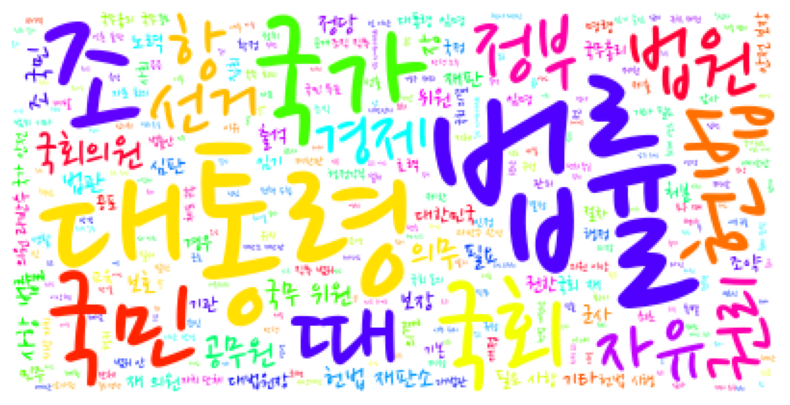

In [71]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white',
                max_words=300,
                colormap='hsv',
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [74]:
# 불용어 처리
from wordcloud import STOPWORDS # 영어권 등록된 불용어 셋
from nltk.corpus import stopwords
print('라이브러리에 등록된 불용어 언어들 :',stopwords.fileids())
불용어 = {'조', '대통령', '법률'}
print(불용어)

라이브러리에 등록된 불용어 언어들 : ['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish', 'uzbek']
{'대통령', '조', '법률'}


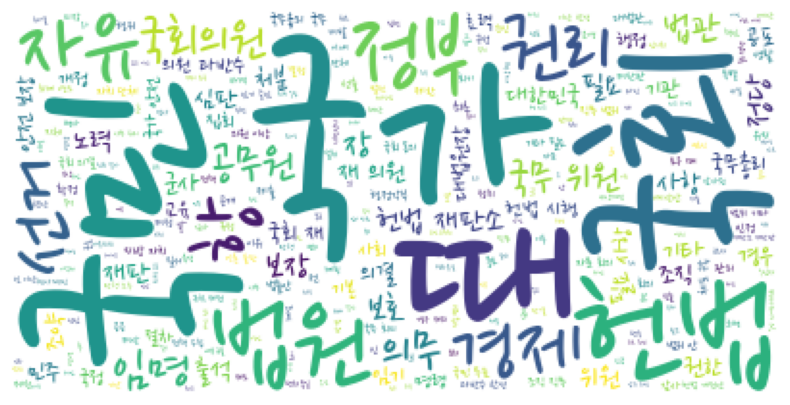

In [75]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, #표시될 최대 단어 수
                colormap='viridis',
                stopwords=불용어,
                # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(1600, 1600, 3) <class 'numpy.ndarray'>


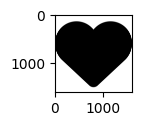

In [76]:
# 워드클라우드의 mask가 될 이미지 -> numpy 배열
# 이미지를 넘파이 배열로 방법1
import cv2
mask = cv2.imread('data/heart.jpg')
plt.figure(figsize=(1,1))
plt.imshow(mask)
print(mask.shape, type(mask))

<class 'PIL.JpegImagePlugin.JpegImageFile'> <class 'numpy.ndarray'> (1600, 1600)


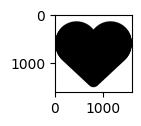

In [77]:
# 이미지를 넘파이 배열로 방법2
from PIL import Image
import numpy as np
img = Image.open('data/heart.jpg')
mask = np.array(img)
plt.figure(figsize=(1,1))
plt.imshow(mask, cmap='gray')
print(type(img), type(mask), mask.shape)

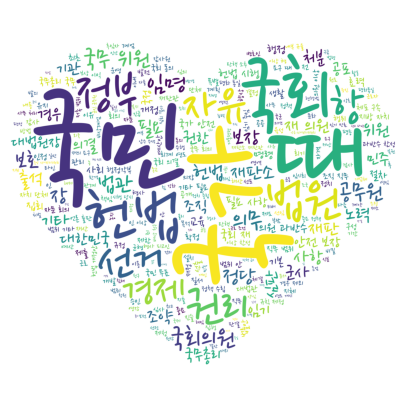

In [78]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, #표시될 최대 단어 수
                colormap='viridis',
                stopwords=불용어,
                mask=mask
                # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

((241, 257, 3), dtype('uint8'))

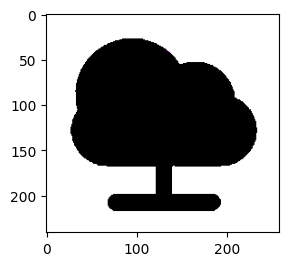

In [79]:
# mask2 = cv2.imread('data/test2.jpg')
# plt.figure(figsize=(3,3))
# plt.imshow(mask2)
# mask2.shape
img = Image.open('data/test2.jpg')
mask2 = np.array(img) # 255흰색, 0:검정색 (uint8)
plt.figure(figsize=(3,3))
mask2 = np.where(mask2>200, 255, 0).astype(np.uint8)
plt.imshow(mask2)
mask2.shape, mask2.dtype

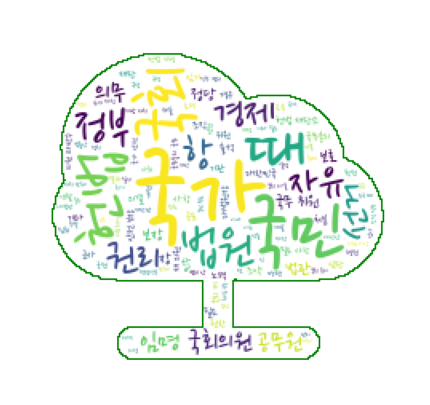

In [80]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, #표시될 최대 단어 수
                colormap='viridis',
                stopwords=불용어,
                mask=mask2,
                contour_width=1,
                contour_color='green'
                # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

((1124, 720, 3), dtype('uint8'))

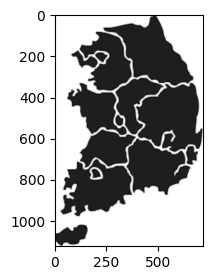

In [81]:
# mask2 = cv2.imread('data/test2.jpg')
# plt.figure(figsize=(3,3))
# plt.imshow(mask2)
# mask2.shape
# 1채널 이미지 -> 3채널 변환
img = Image.open('data/south_korea.png').convert('RGB')
mask2 = np.array(img) # 255흰색, 0:검정색 (uint8)
plt.figure(figsize=(3,3))
plt.imshow(mask2)
mask2.shape, mask2.dtype

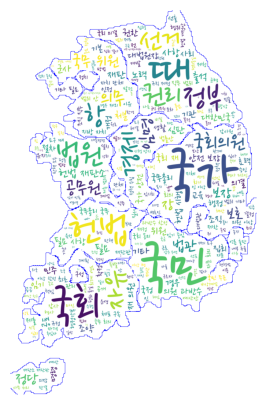

In [82]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, #표시될 최대 단어 수
                colormap='viridis',
                stopwords=불용어,
                mask=mask2,
                contour_width=1,
                contour_color='blue'
                # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

## 단어의 빈도수 시각화

In [83]:
# 한글 설정(Win/MacOS)
# plt.rc('font', family='Malgun Gothic') # 윈도우즈
# plt.rc('font', family='AppleGothic') # Mac
# plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (20,4)

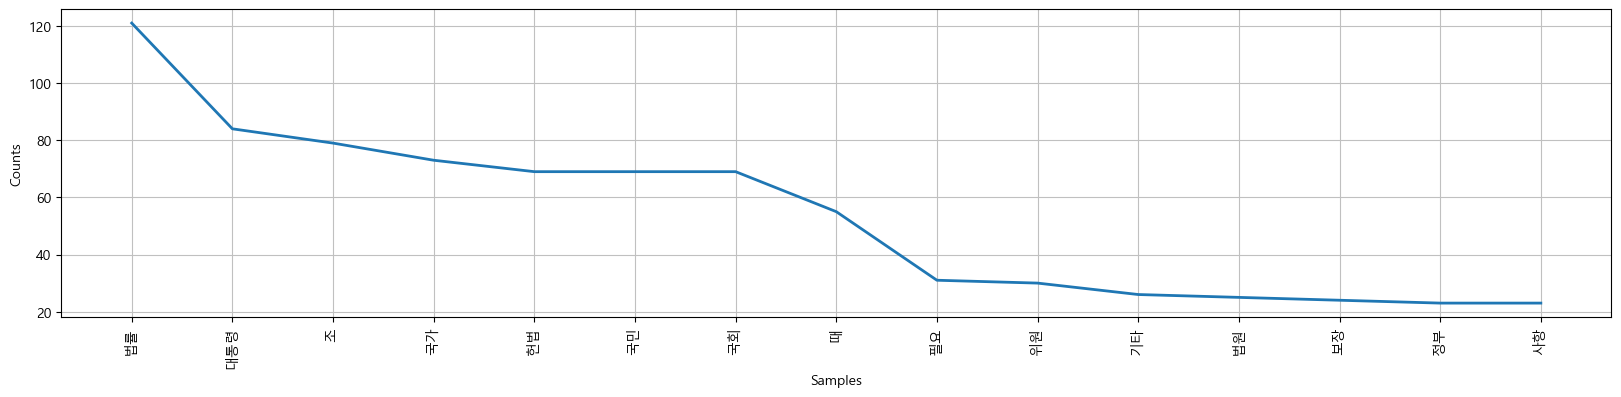

<Axes: xlabel='Samples', ylabel='Counts'>

In [84]:
from nltk import Text
data_text = Text(noun_list)
data_text.plot(15)

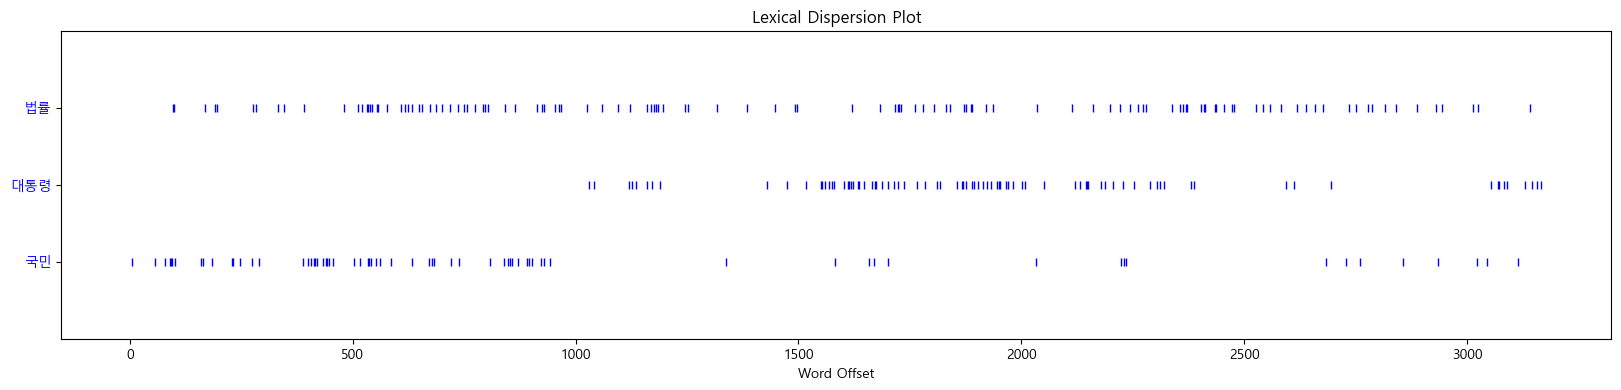

In [85]:
data_text.dispersion_plot(['법률', '대통령','국민'])

# 6. 워드 임베딩
- 단어간 벡터 계산
- Word2vec은 주변 같이 나오는 단어는 의미가 유사하는 아이디어로 단어를 숫자 좌표로 바꿔서 계산

- 경제뉴스 20개를 각각 명사만 가져와서 list (naver API)

In [88]:
# .env 가져오기(방법1) - 강추
from dotenv import load_dotenv
import os
load_dotenv()
# print(os.getenv('CLIENT_ID'))
# print(os.getenv('CLIENT_SECRET'))

True

In [90]:
# .env가져오기(방법2) - 주피터환경에서 안 될 수도 있음
from decouple import config
# print(config('CLIENT_ID'))
# print(config('CLIENT_SECRET'))

In [105]:
import os
import requests
import json
import pandas as pd
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

url = f"https://openapi.naver.com/v1/search/news.json" # JSON 결과
params = {
    'query':'경제', 
    'display':20 , # 가져올 데이터 갯수(기본값은 10)
    'sort':'date' # 최신순 뉴스
         }
headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
response = requests.get(url, params=params, headers=headers)

items = response.json()['items'] # response를 json형태로 변환한것 중 'items'
# 제목(title) + ' ' + 요약(description) 텍스만 추출하여 list
news_texts = []
for item in items:
    title = item.get('title').replace('<b>', ' ').replace('</b>', ' ')
    description = item.get('description').replace('<b>', ' ').replace('</b>', ' ')
    news_texts.append(title + ' ' + description)
news_texts[:3], len(news_texts)

(['“2.9억 할랄시장 잡아라”…무협, K소비재 200개사 자카르타로 경기창조 경제 혁신센터 14개사, 코트라 30개사, 한국여성벤처협회 15개사, 김포상공회의소 5개사... 현장을 찾은 구자열 한국무역협회 명예회장은 “인도네시아는 높은  경제  성장세와 두터운 젊은 층을 바탕으로 K... ',
  '이상조 청주시의원 &quot;현장에서 답 찾는 의회···소통과 협치로 시민 신... 초선이던 3대 청주시의회에서부터 청주 원도심의 현안 해결과 지역 경제  활성화를 위해 현장을 누벼온 이 의원이 재선 의원으로서 국민의힘 원내대표라는 새로운 역할까지 맡으면서다. 이 의원은 현재 청주시의회  경제 문화... ',
  '대덕세무서 신설 순항… 내년 정부예산안에 14.4억 담겼다 대전  경제 계 숙원사업인 (가칭)대덕세무서 신설이 내년 정부 예산안에 반영되면서 속도를 내고 있다. 지난달 행정안전부 정기직제 심사를 통과한 데 이어 정부 예산안에도 신설 관련 예산이 담기면서 개청을 위한 행정... '],
 20)

In [106]:
# 명사추출(news_texts)
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer = MeCab()
news = []
for article in news_texts:
    noun_list = analyzer.nouns(article)
    noun_list = [word for word, tag in analyzer.pos(article) if tag in ('NNG','NNP')]
    news.append(noun_list)
print(news[:3])

[['할랄', '시장', '무협', '소비재', '자카르타', '경기', '창조', '경제', '혁신', '센터', '코트', '한국', '여성', '벤처', '협회', '김포', '상공', '회의소', '현장', '구자열', '한국', '무역', '협회', '명예', '회장', '인도네시아', '경제', '성장세', '층', '바탕'], ['이상조', '청주시', '의원', '현장', '답', '의회', '소통', '협', '시민', '신', '초선', '청주시', '의회', '청주', '원도', '심의', '현안', '해결', '지역', '경제', '활성', '현장', '의원', '재선', '의원', '국민', '힘', '원내대표', '역할', '의원', '청주시', '의회', '경제', '문화'], ['대덕', '세무서', '신설', '순항', '내년', '정부', '예산안', '대전', '경제', '숙원', '사업', '가칭', '대덕', '세무서', '신설', '내년', '정부', '예산안', '반영', '속도', '지난달', '행정', '정기', '직제', '심사', '통과', '정부', '예산안', '신설', '관련', '예산', '개청', '행정']]


In [107]:
print([len(nouns) for nouns in news])

[30, 34, 33, 29, 30, 33, 35, 35, 27, 38, 35, 34, 40, 33, 39, 30, 36, 28, 36, 24]


In [108]:
# 워드 임베팅(단어간 거리 계산)
from gensim.models import Word2Vec
model = Word2Vec(news, # 2차원 학습데이터
                window=15, # 각 단어의 좌우 15개 단어를 학습 컨텐츠로 사용
                min_count=2, # 2회 이상 등장한 단어만 학습
                workers=-1,  # 병렬처리 core갯수 (-1:모든 가용 core 다 사용)
                sg=1) # 소량 데이터에서의 학습방식 / 대량 데이터에서는 0

In [109]:
# 학습한 단어 리스트
print(model.wv.index_to_key)

['경제', '지역', '의원', '수소', '이전', '베트남', '계획', '정책', '국토', '기관', '공공', '정치', '시즌', '행정', '정부', '광주', '위원장', '시', '현황', '대응', '부담', '연장', '부', '사회', '금융', '삼성전자', '이익', '추진', '개발', '네이버', '이번', '사업', '대전', '예산안', '신설', '의회', '청주시', '현장', '가능', '시설', '분석', '여건', '주택', '주거지', '노후', '전체', '지방', '인천', '유럽', '김치', '확장', '시당', '신임', '김', '판사', '부장', '정비', '수급', '불안', '인프라', '관광', '규모', '안산선', '성격', '서민', '기능', '이날', '장관', '교통부', '종합', '마련', '판로', '장터', '직거래', '창업', '지원', '신한은행', '기업', '관내', '매출', '업체', '행사', '추석', '남양주시', '감소', '컨소시엄', '클라우드', '모델', '보안', '외교', '국제', '학과', '선택', '정치학', '관련', '내년', '세무서', '대덕', '힘', '해결', '시민', '협회', '여성', '한국', '시장']


In [111]:
# 유사도가 가장 높은 단어(거리가 가까운 단어) 10개(topn)
model.wv.most_similar('미국', topn=10) 

KeyError: "Key '미국' not present in vocabulary"

In [103]:
model.wv.most_similar('추석', topn=10) 

KeyError: "Key '추석' not present in vocabulary"

In [104]:
# 단어를 입력받아 유사한 단어 5개 출력하기
word = input('유사도를 알고 싶은 단어는?')
if word in model.wv:
    print(model.wv.most_similar(word, topn=5))
else:
    print(f'{word} 단어가 훈련 데이터에 없습니다')

유사도를 알고 싶은 단어는?ㅁ
ㅁ 단어가 훈련 데이터에 없습니다
